# Campaign property trends

Manual, read-only exploration of every `data/results/begins_*/agg.csv`. Each marker is a sample mean and each error bar is **±1 intra-sample standard deviation**. Actual raw specimen timestamps are used when available; processing timestamps are the fallback.

Run the cells from top to bottom. Edit only the settings cell for normal use.

In [147]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt

# Works whether Jupyter starts in the repository root or EVALUATE/.
repo_root = Path.cwd() if (Path.cwd() / 'data').is_dir() else Path.cwd().parent
evaluate_dir = repo_root / 'EVALUATE'
if str(evaluate_dir) not in sys.path:
    sys.path.insert(0, str(evaluate_dir))

from campaign_trends import (
    available_properties, export_campaign, load_campaign_data,
    plot_properties, select_campaign,
)

## Settings

In [148]:
PROPERTIES = [
    'Thickness',
    'Elastic Modulus',
    'Yield Strength',
    'Pore Fraction',
    'Creep Strain',
    'Strain at 50 bar',
]
START = None       # Example: '2026-08-10'
END = None         # Example: '2026-08-22' (the full day is included)
CAMPAIGNS = None   # Example: ['2026-08-20-exploration-mode']; None means all
CONNECT_POINTS = True
SAVE_OUTPUTS = False
CHEMISTRY_FILTER = 'Polysulfone / PolarClean (inferred)'  # Set to None for every chemistry

## Campaign interpretation

The dated `llm.csv` suggestions identify the campaign intent as follows:

- **Aug 11–20 afternoon:** directed mechanical optimization. The suggestions repeatedly state the primary objective is to maximize Elastic Modulus and the secondary objective is to minimize Strain at 50 bar. The 17 wt%, additive-free formulation is treated as Polysulfone/PolarClean.
- **From Aug 20 exploration-mode onward:** deliberate design-space exploration. The LLM suggestions explicitly prioritize sparse-region coverage, while retaining modulus/strain as downstream objectives.

These labels are campaign-level interpretations, not analytical identification of the chemicals. Change `PHASES` below if laboratory records provide more exact boundaries. Dashed lines are the running best achieved value: upper envelope for maximization and lower envelope for minimization.

In [149]:
import pandas as pd
import matplotlib.dates as mdates
from matplotlib.patches import Patch

# Boundaries inferred from the dated LLM suggestions. None means extend to plot edge.
PHASES = [
    dict(start=None, end='2026-08-20 16:30',
         label='Polysulfone / PolarClean\nmaximize modulus; minimize strain', color='#7fc8a9'),
    dict(start='2026-08-20 16:30', end=None,
         label='Polysulfone / PolarClean\nexplorative design-space coverage', color='#91b7e8'),
]

# Direction is based on the objectives stated in the LLM suggestions. Add/edit as needed.
GOAL_DIRECTION = {
    'Elastic Modulus': 'maximize',
    'Yield Strength': 'maximize',
    'Strain at 50 bar': 'minimize',
    'Strain at 80 bar': 'minimize',
    'Strain at 150 bar': 'minimize',
    'Strain at 500 bar': 'minimize',
}

def infer_chemistry(row):
    """Notebook-only heuristic supplied with the campaign context."""
    polymer = pd.to_numeric(row.get('polymer_wt'), errors='coerce')
    additive = pd.to_numeric(row.get('additive_wt'), errors='coerce')
    name = str(row.get('condition', ''))
    if (pd.notna(polymer) and polymer >= 20 and pd.notna(additive) and additive > 0) or (name.startswith('21-') and not name.startswith('21-0add')):
        return 'Primospire / NMP + PVP (inferred)'
    if (pd.notna(polymer) and polymer >= 20) or name.startswith('21-'):
        return 'Primospire / NMP, no PVP (inferred)'
    if pd.notna(polymer) and polymer <= 17:
        return 'Polysulfone / PolarClean (inferred)'
    return 'Unclassified formulation'

def _shade_phases(ax, points):
    for phase in PHASES:
        mask = pd.Series(True, index=points.index)
        if phase['start'] is not None:
            mask &= points['sample_time'] >= pd.Timestamp(phase['start'])
        if phase['end'] is not None:
            mask &= points['sample_time'] < pd.Timestamp(phase['end'])
        phase_iterations = points.loc[mask, 'iteration']
        if not phase_iterations.empty:
            ax.axvspan(phase_iterations.min() - 0.5, phase_iterations.max() + 0.5,
                       color=phase['color'], alpha=0.18, zorder=0)

def plot_detailed_campaign(data, properties, color_column, color_label, *,
                           nitrogen_markers=False, columns=2, connect_points=True, cmap='viridis'):
    """Plot one campaign view with a selectable color variable and fixed marker size."""
    import math
    properties = list(properties)
    columns = max(1, min(columns, len(properties)))
    rows = math.ceil(len(properties) / columns)
    fig, grid = plt.subplots(rows, columns, figsize=(8.5 * columns, 5.2 * rows), squeeze=False)
    axes = list(grid.flat)
    valid_times = data['sample_time'].dropna()
    minimum_time, maximum_time = valid_times.min(), valid_times.max()
    enriched = data.copy()
    enriched['chemistry'] = enriched.apply(infer_chemistry, axis=1)
    enriched = enriched.sort_values('sample_time').reset_index(drop=True)
    enriched['iteration'] = enriched.index + 1
    color_values = pd.to_numeric(enriched[color_column], errors='coerce')
    color_min, color_max = color_values.min(), color_values.max()
    if color_min == color_max:
        color_min -= 0.5
        color_max += 0.5
    normalization = plt.Normalize(color_min, color_max)
    color_map = plt.get_cmap(cmap)
    def nitrogen_is_on(value):
        return value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}
    for ax, prop in zip(axes, properties):
        mean_col, sd_col = f'{prop} Mean', f'{prop} SD'
        points = enriched.dropna(subset=['sample_time', mean_col]).sort_values('sample_time')
        _shade_phases(ax, enriched)
        if connect_points:
            ax.plot(points['iteration'], points[mean_col], color='#707070', lw=0.9, alpha=0.55, zorder=2)
        point_color_values = pd.to_numeric(points[color_column], errors='coerce').fillna(color_values.median())
        point_colors = color_map(normalization(point_color_values))
        for (_, point), color in zip(points.iterrows(), point_colors):
            error = pd.to_numeric(pd.Series([point.get(sd_col)]), errors='coerce').fillna(0).iloc[0]
            marker = ('o' if nitrogen_is_on(point.get('nitrogen')) else 's') if nitrogen_markers else 'o'
            ax.errorbar(point['iteration'], point[mean_col], yerr=error,
                        fmt=marker, linestyle='none', color=color, ecolor=color,
                        markeredgecolor='black', markeredgewidth=1.2,
                        markersize=11, capsize=4, elinewidth=1.3, zorder=3)
        direction = GOAL_DIRECTION.get(prop)
        if direction:
            values = pd.to_numeric(points[mean_col], errors='coerce')
            running_best = values.cummax() if direction == 'maximize' else values.cummin()
            ax.step(points['iteration'], running_best, where='post', color='#b21f35',
                    linestyle='--', linewidth=1.6,
                    label=f'Running best ({direction})', zorder=4)
        ax.set_title(prop, fontsize=20, fontweight='semibold', pad=12)
        ax.set_xlabel('Iteration (chronological order)', fontsize=16, labelpad=9)
        ax.set_ylabel(f'{prop} (mean ± SD)', fontsize=13, labelpad=8)
        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.label.set_size(16)
        ax.grid(True, alpha=0.22)
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_xlim(0.5, len(enriched) + 0.5)
    for ax in axes[len(properties):]:
        ax.remove()
    phase_handles = [Patch(facecolor=p['color'], alpha=.25, label=p['label']) for p in PHASES]
    goal_handle = plt.Line2D([], [], color='#b21f35', linestyle='--', label='Optimization goal: running best')
    nitrogen_handles = [
        plt.Line2D([], [], marker='o', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen on'),
        plt.Line2D([], [], marker='s', markersize=13, markerfacecolor='#888888', markeredgecolor='black', linestyle='none', label='Nitrogen off'),
    ]
    legend_handles = phase_handles + [goal_handle] + (nitrogen_handles if nitrogen_markers else [])
    fig.legend(handles=legend_handles,
               loc='lower center', bbox_to_anchor=(0.5, 0.12),
               ncol=4, frameon=False, fontsize=13, labelspacing=1.0, columnspacing=1.5)
    color_scale = plt.cm.ScalarMappable(norm=normalization, cmap=color_map)
    color_scale.set_array([])
    # A dedicated axis keeps the color scale clear of the right-hand plots.
    fig.subplots_adjust(left=0.09, right=0.87, bottom=0.25, top=0.90, wspace=0.32, hspace=0.42)
    colorbar_axis = fig.add_axes([0.915, 0.25, 0.018, 0.55])
    colorbar = fig.colorbar(color_scale, cax=colorbar_axis)
    colorbar.set_label(color_label, fontsize=16, labelpad=14)
    colorbar.ax.tick_params(labelsize=14)
    fig.suptitle(f'Polysulfone / PolarClean properties — color: {color_label}',
                 fontsize=22, fontweight='semibold')
    return fig, axes[:len(properties)], enriched

In [150]:
all_data = load_campaign_data(repo_root / 'data' / 'results', repo_root / 'data' / 'raw')
campaign = select_campaign(all_data, start=START, end=END, campaigns=CAMPAIGNS)
campaign['chemistry'] = campaign.apply(infer_chemistry, axis=1)
if CHEMISTRY_FILTER is not None:
    campaign = campaign[campaign['chemistry'] == CHEMISTRY_FILTER].copy()
property_mean_columns = [f'{prop} Mean' for prop in PROPERTIES]
campaign = campaign[campaign[property_mean_columns].notna().any(axis=1)].copy()
campaign = campaign[pd.to_numeric(campaign['Thickness Mean'], errors='coerce') >= 70].copy()
# Remove the incomplete 10 wt% baseline; the retained PolarClean campaign spans 13–17 wt%.
campaign = campaign[pd.to_numeric(campaign['polymer_wt'], errors='coerce') >= 13].copy()
print(f'{len(campaign)} samples from {campaign.sample_time.min()} to {campaign.sample_time.max()}')
print('Available properties:', available_properties(campaign))
campaign[['sample_time', 'condition', 'campaign', 'chemistry', 'time_source']].head()

46 samples from 2026-08-14 19:51:41 to 2026-09-01 02:55:37
Available properties: ['Creep Strain', 'Elastic Modulus', 'Pore Fraction', 'Slope Densification', 'Slope Plateau', 'Strain at 150 bar', 'Strain at 50 bar', 'Strain at 500 bar', 'Strain at 80 bar', 'Thickness', 'Yield Strength']


,sample_time,condition,campaign,chemistry,time_source
14,2026-08-14 19:51:41,17-0add-5deg-30s-N2-125s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
15,2026-08-14 20:39:10,17-0add-5deg-60s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
16,2026-08-14 21:55:19,17-0add-5deg-90s-N2-1800s_run2,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
17,2026-08-14 23:14:19,17-0add-5deg-120s-N2-1800s,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename
18,2026-08-15 00:32:14,17-0add-5deg-90s-N2-1800s_run3,2026-08-14,Polysulfone / PolarClean (inferred),raw specimen filename


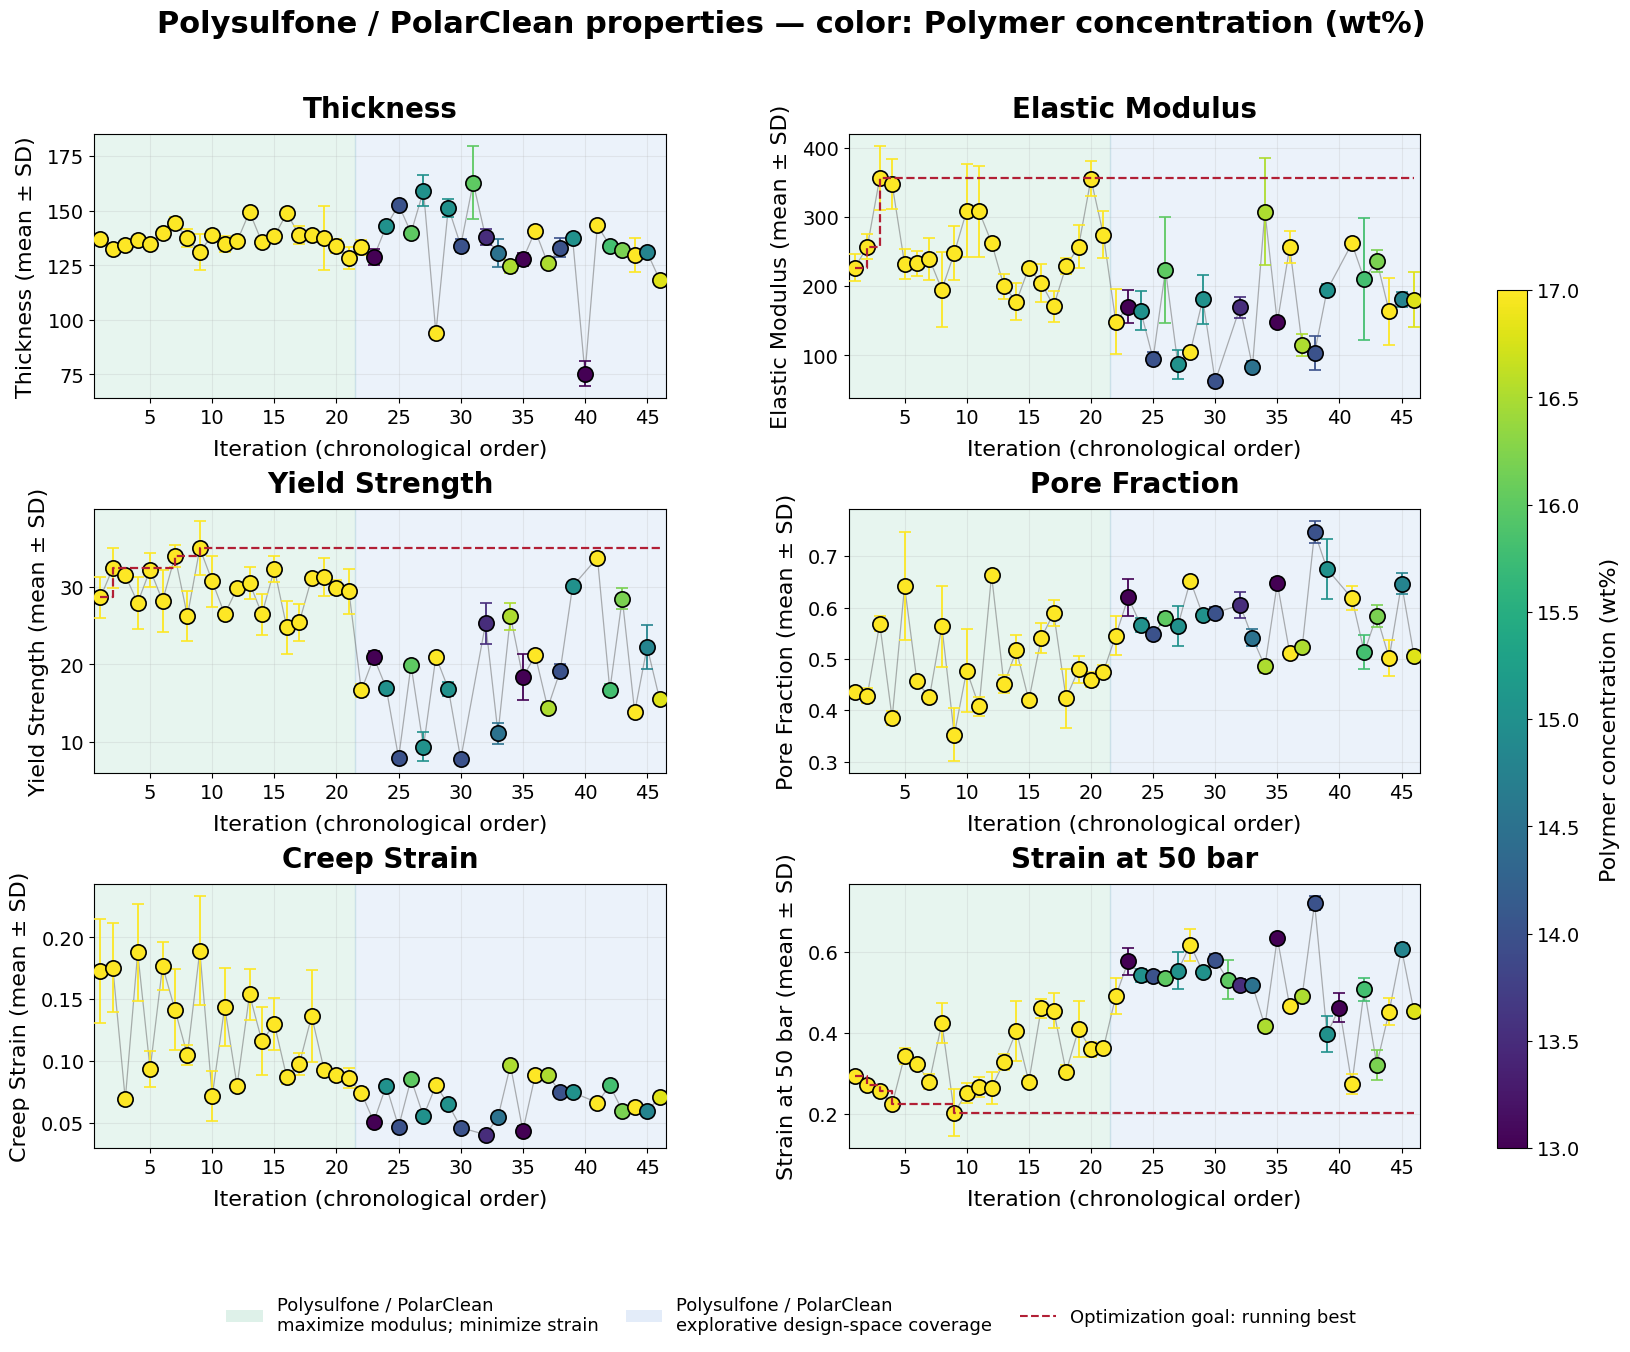

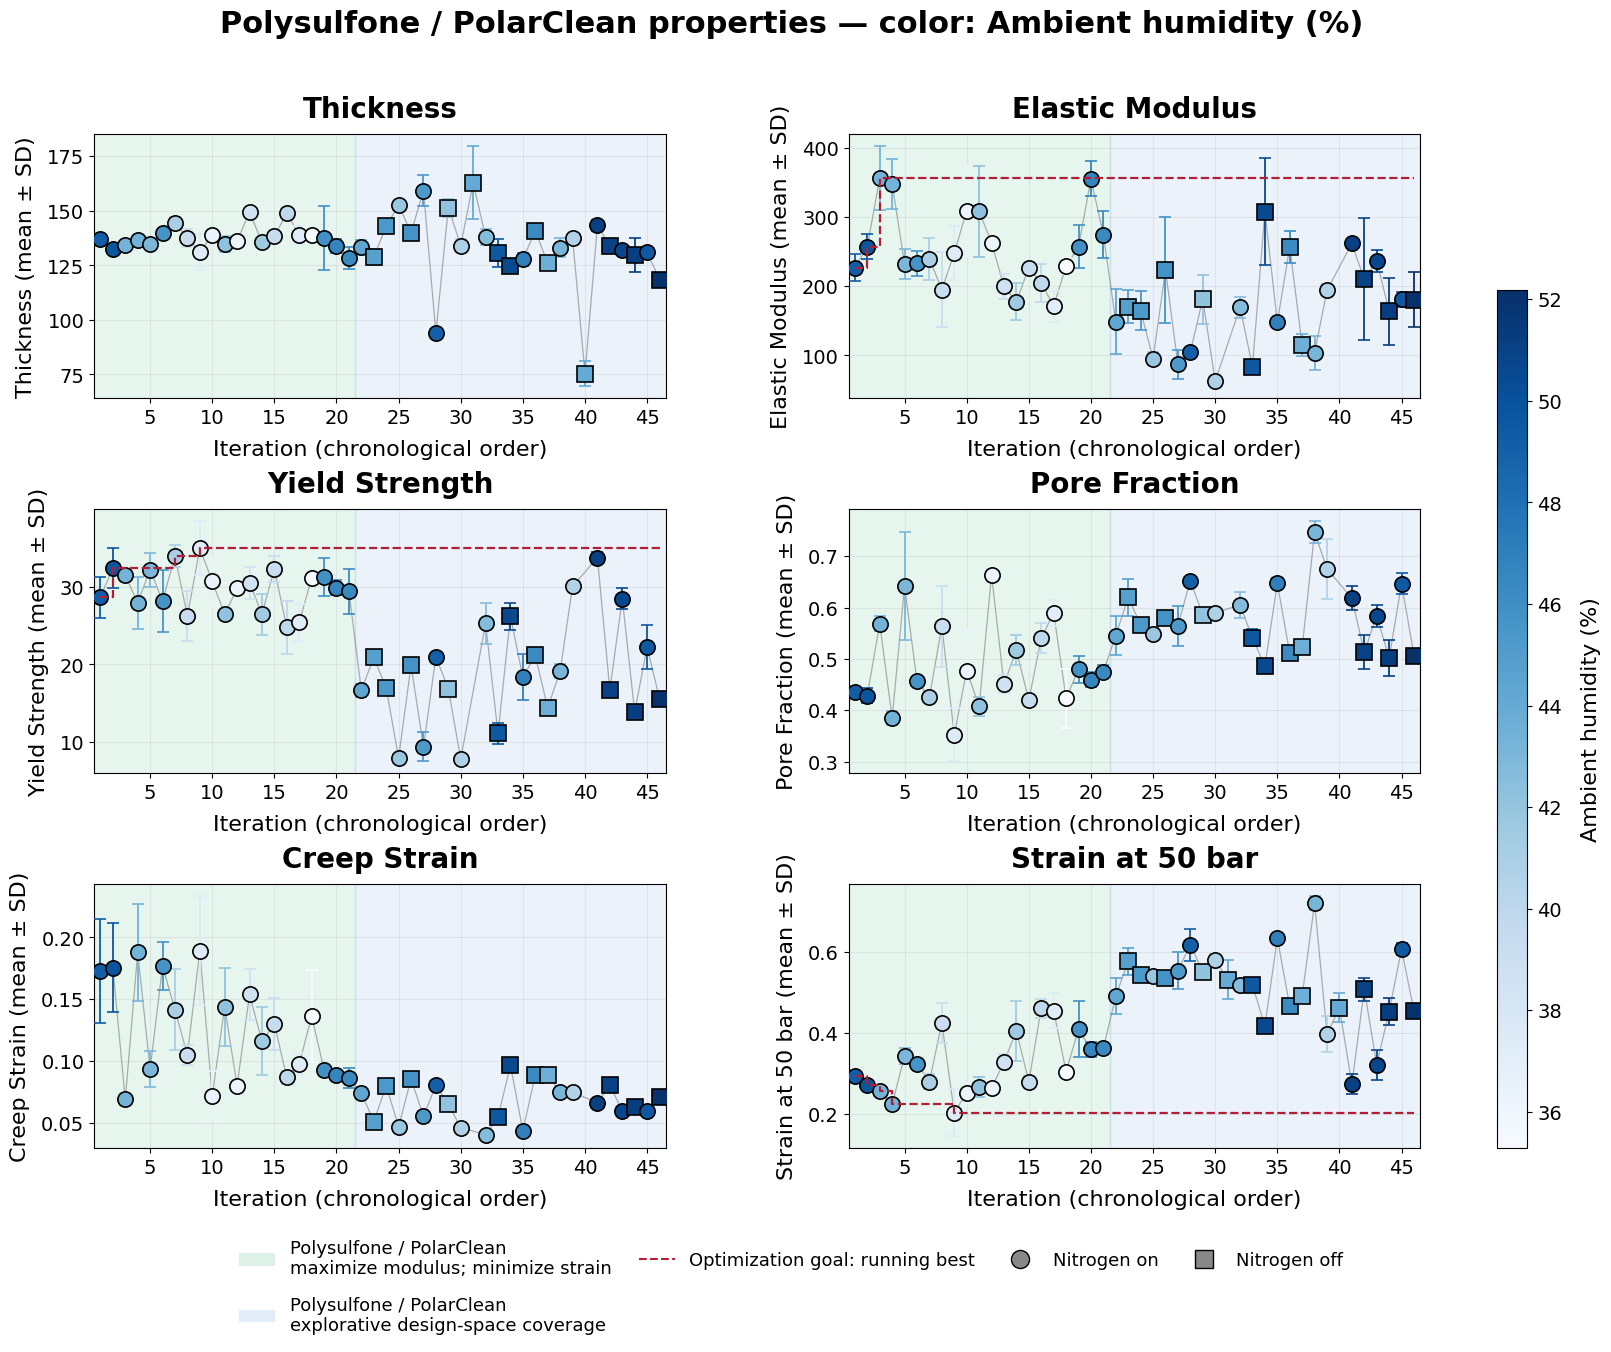

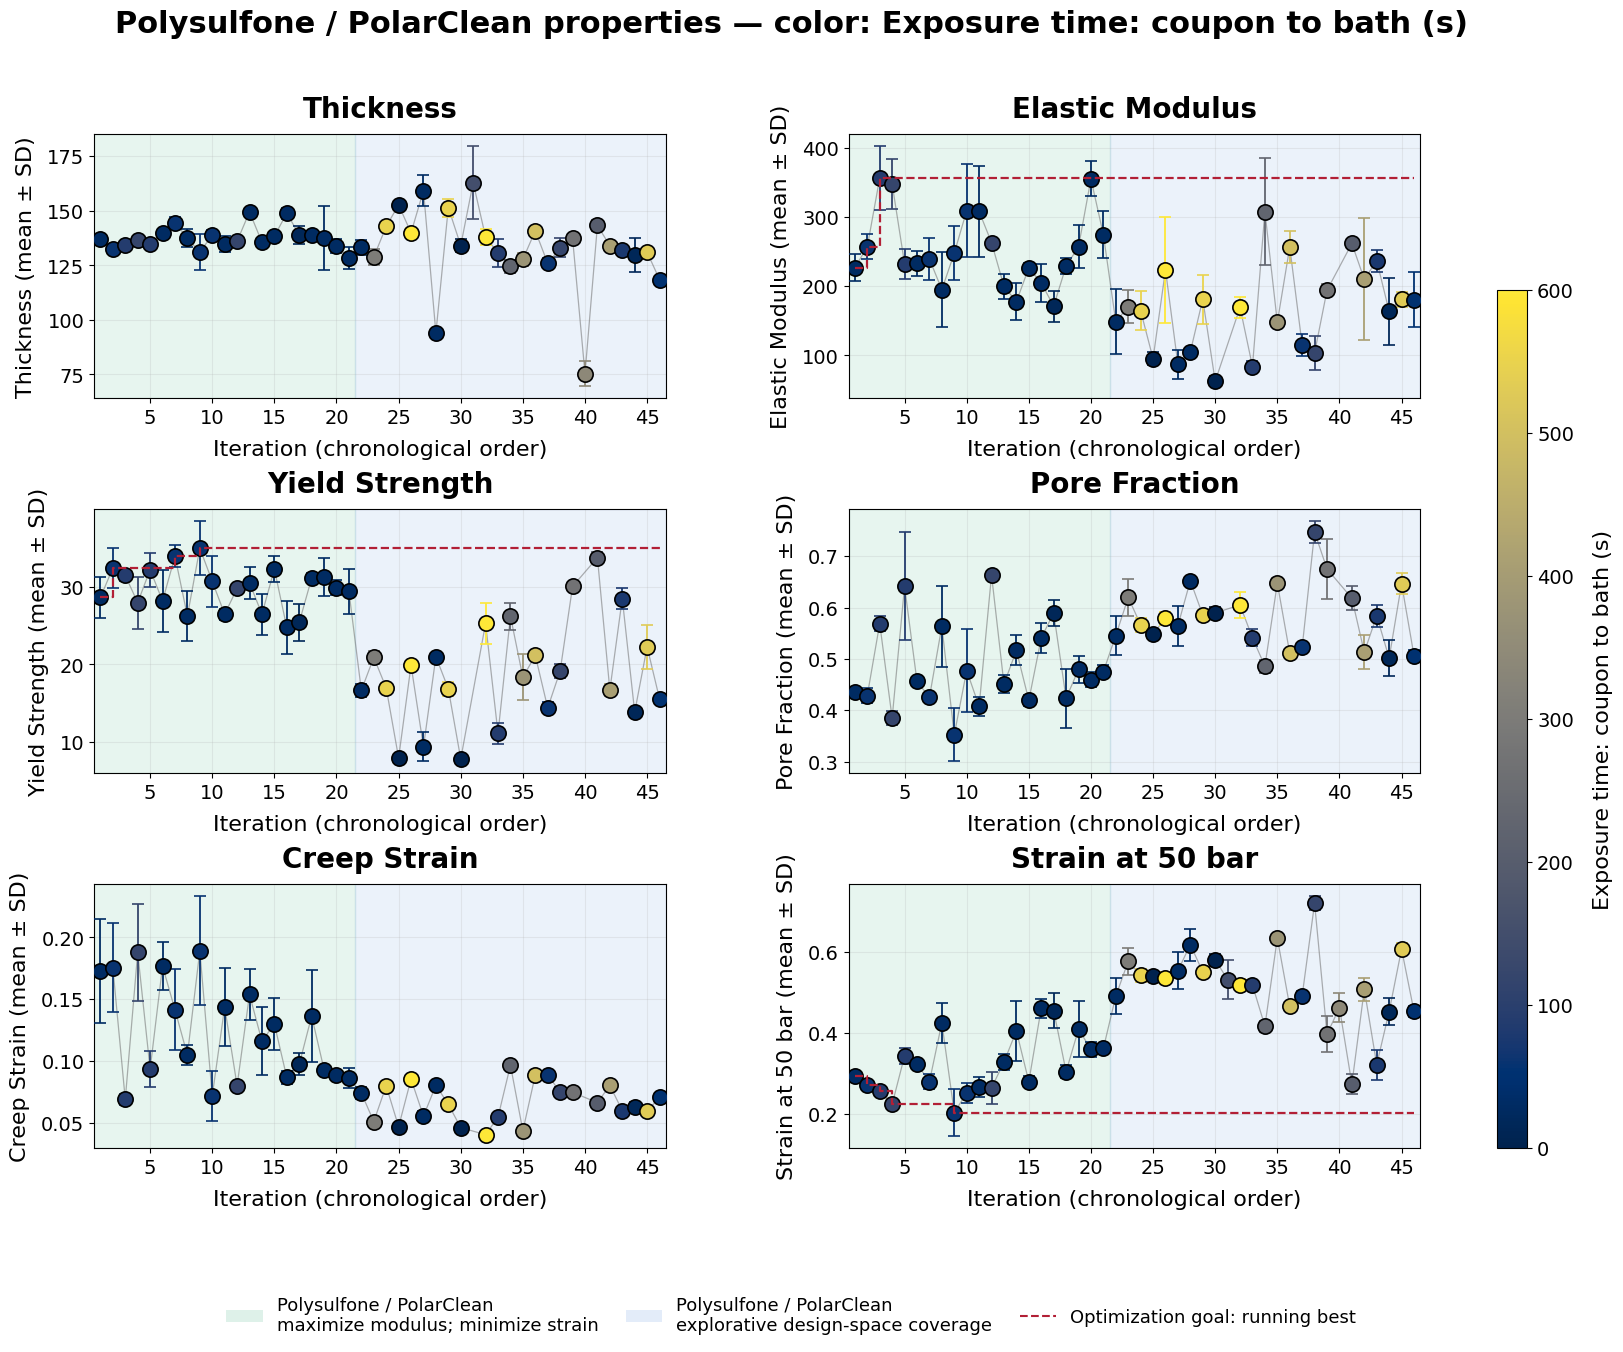

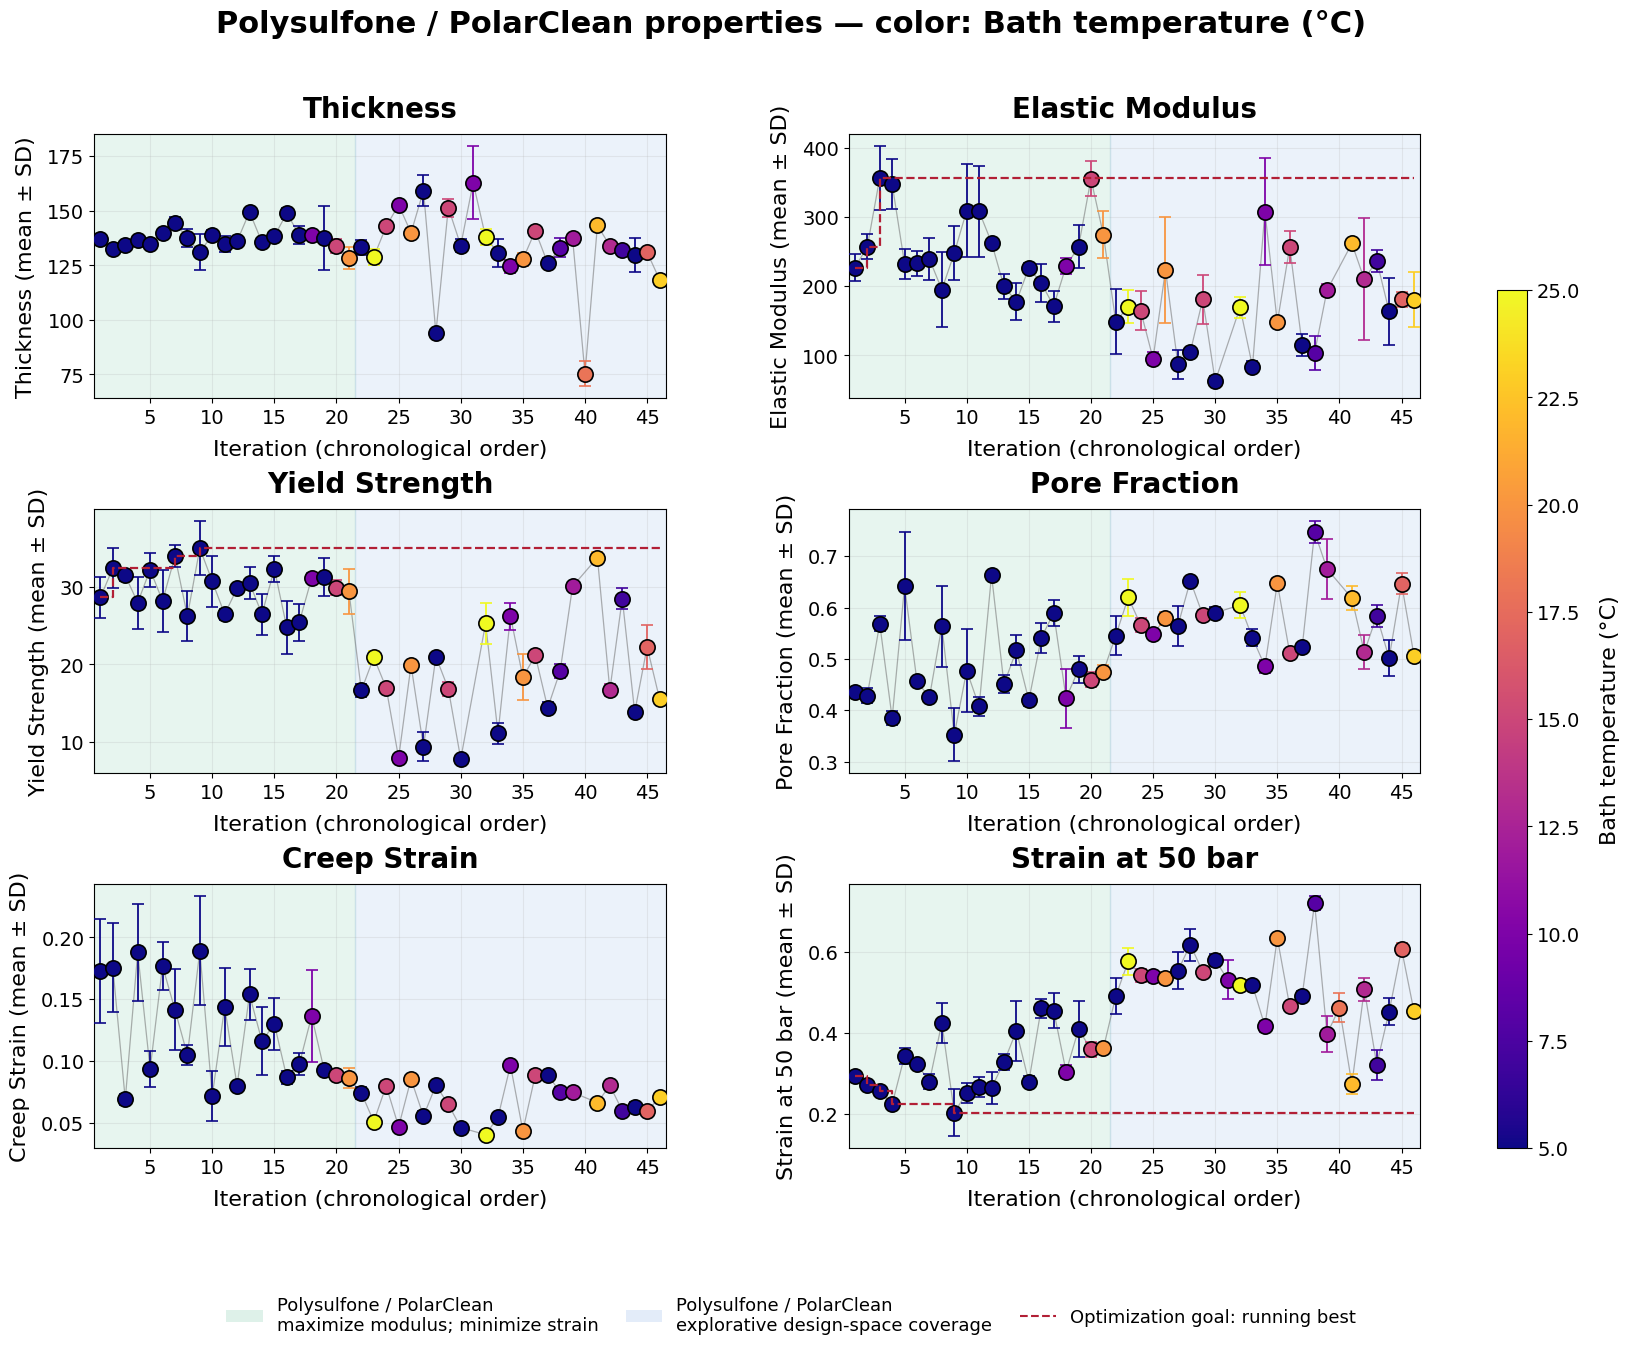

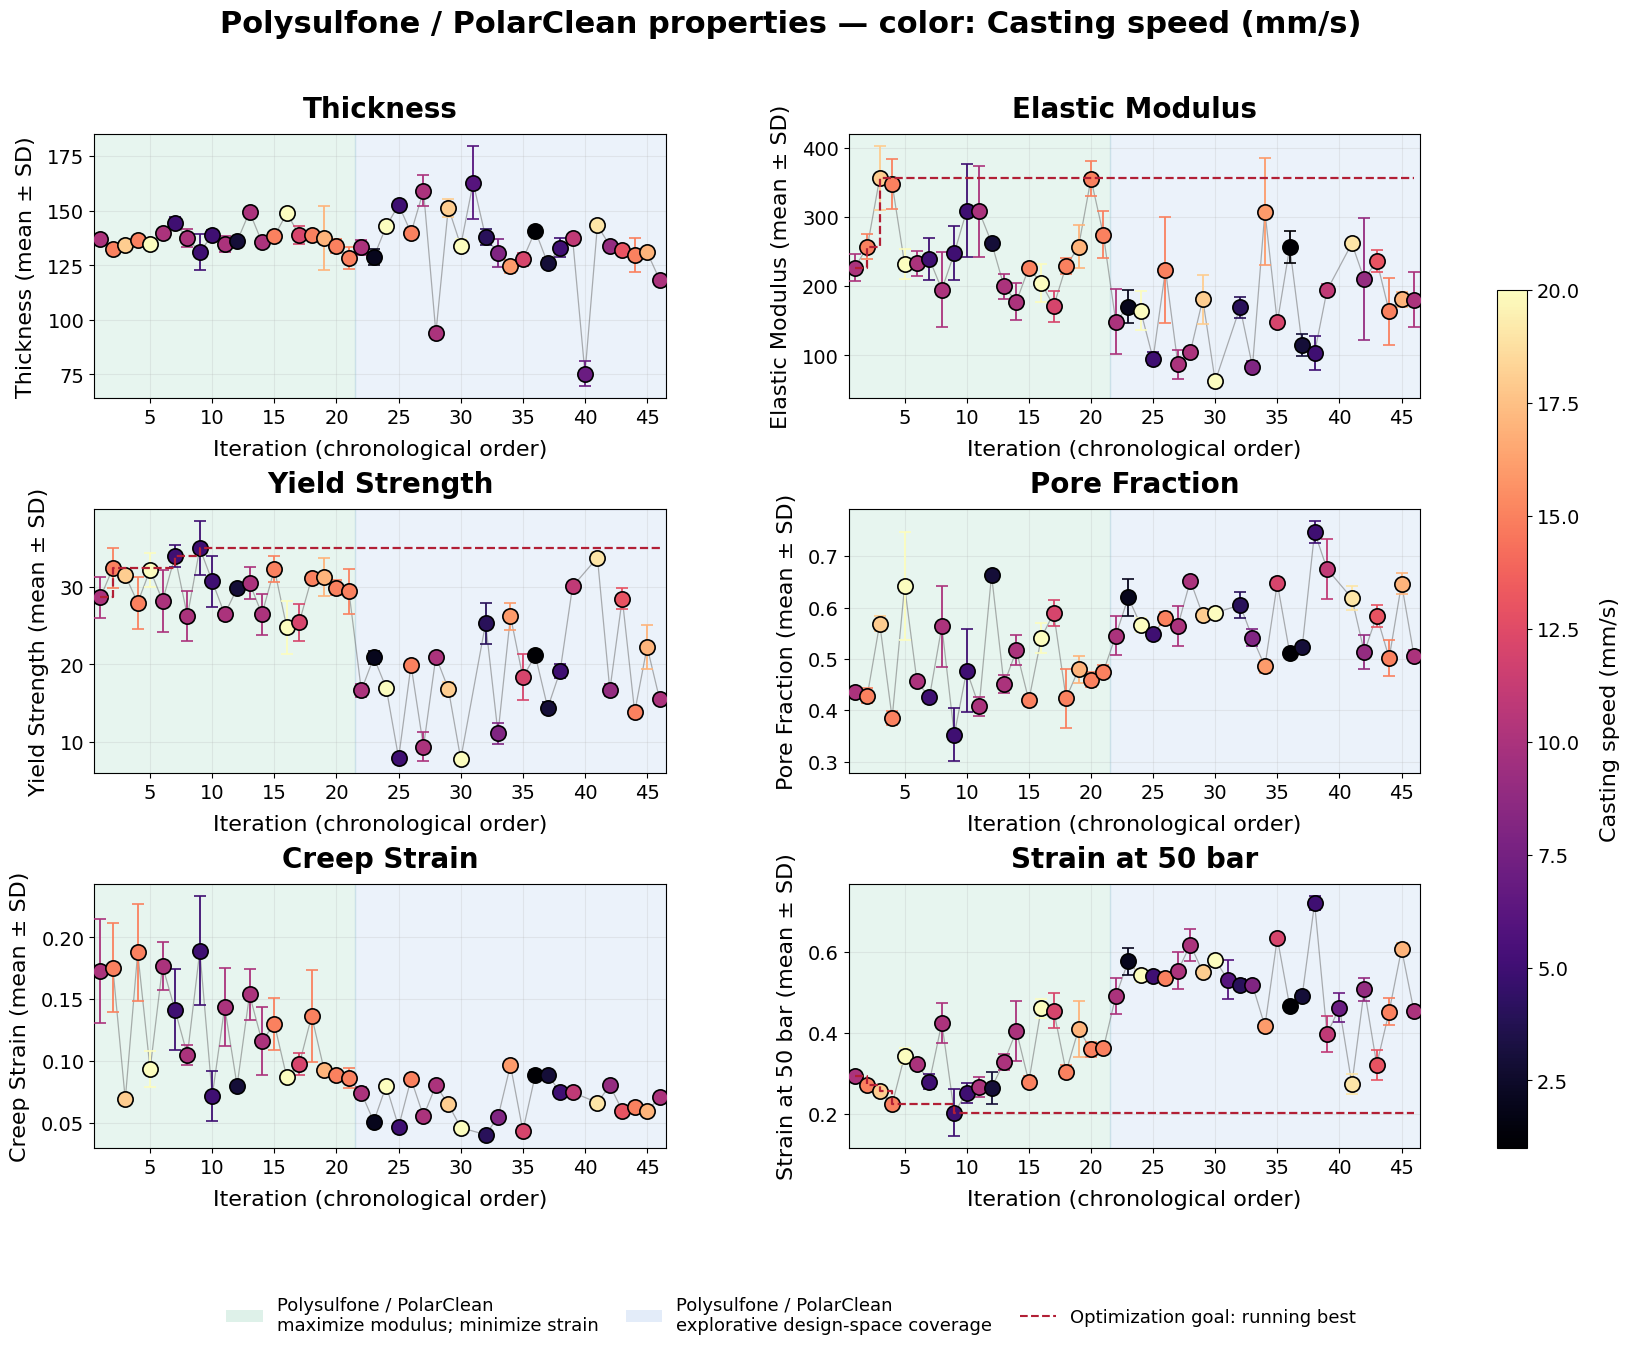

In [151]:
figure_polymer, axes_polymer, campaign_detailed = plot_detailed_campaign(
    campaign, PROPERTIES, 'polymer_wt', 'Polymer concentration (wt%)',
    connect_points=CONNECT_POINTS, cmap='viridis'
)
figure_humidity, axes_humidity, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'Humidity Mean', 'Ambient humidity (%)',
    nitrogen_markers=True, connect_points=CONNECT_POINTS, cmap='Blues'
)
figure_exposure, axes_exposure, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'coupon_to_bath_wait_time', 'Exposure time: coupon to bath (s)',
    connect_points=CONNECT_POINTS, cmap='cividis'
)
figure_bath, axes_bath, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'bath_temp', 'Bath temperature (°C)',
    connect_points=CONNECT_POINTS, cmap='plasma'
)
figure_casting, axes_casting, _ = plot_detailed_campaign(
    campaign, PROPERTIES, 'pullcast_speed', 'Casting speed (mm/s)',
    connect_points=CONNECT_POINTS, cmap='magma'
)
plt.show()

## Cross-validated feature importance

This section estimates which controllable and environmental variables are most useful for predicting each selected property. It uses a regularized linear (ridge) model with repeated **permutation importance on held-out folds**. Importance is the increase in held-out mean absolute error after shuffling one feature; larger positive values indicate greater predictive value.

The heatmap normalizes positive importances within each response so patterns can be compared across properties with different units. The detailed table retains raw mean importance and fold/repeat variability. With only about 31 samples, treat these rankings as exploratory associations—not causal effects. Correlated process settings may share or mask importance.

In [152]:
import numpy as np

FEATURES = {
    'polymer_wt': 'Polymer concentration',
    'mixing_temp': 'Mixing temperature',
    'bath_temp': 'Bath temperature',
    'pullcast_speed': 'Casting speed',
    'nitrogen': 'Nitrogen on/off',
    'coupon_to_bath_wait_time': 'Exposure time',
    'nips_bath_wait_time': 'Bath residence time',
    'Humidity Mean': 'Ambient humidity',
}
MIN_TARGET_SAMPLES = 12
N_PERMUTATION_REPEATS = 20
RANDOM_STATE = 42
RIDGE_ALPHA = 1.0
FEATURE_IMPORTANCE_PROPERTIES = list(PROPERTIES) + ['CV']

def nitrogen_to_binary(value):
    """Convert CSV boolean/string nitrogen values without relying on another cell."""
    return 1 if (value is True or str(value).strip().lower() in {'true', '1', 'yes', 'on'}) else 0

def cross_validated_permutation_importance(data, properties, features=FEATURES):
    records = []
    for property_name in properties:
        target_column = f'{property_name} Mean'
        usable = data.dropna(subset=[target_column]).copy()
        if len(usable) < MIN_TARGET_SAMPLES:
            print(f'Skipping {property_name}: only {len(usable)} usable samples')
            continue
        X = usable[list(features)].copy()
        X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
        X = X.apply(pd.to_numeric, errors='coerce')
        # Drop constants: they cannot have permutation importance in this subset.
        variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
        X = X[variable_columns]
        y = pd.to_numeric(usable[target_column], errors='coerce')
        splits = min(5, max(3, len(usable) // 5))
        random_generator = np.random.RandomState(RANDOM_STATE)
        shuffled_indices = random_generator.permutation(len(X))
        validation_folds = np.array_split(shuffled_indices, splits)
        fold_importances = []
        for fold, test_index in enumerate(validation_folds, start=1):
            train_index = np.setdiff1d(shuffled_indices, test_index)
            X_train_frame, X_test_frame = X.iloc[train_index], X.iloc[test_index]
            medians = X_train_frame.median()
            X_train = X_train_frame.fillna(medians).to_numpy(dtype=float)
            X_test = X_test_frame.fillna(medians).to_numpy(dtype=float)
            center, scale = X_train.mean(axis=0), X_train.std(axis=0)
            scale[scale == 0] = 1
            X_train = (X_train - center) / scale
            X_test = (X_test - center) / scale
            y_train = y.iloc[train_index].to_numpy(dtype=float)
            y_center = y_train.mean()
            coefficients = np.linalg.solve(
                X_train.T @ X_train + RIDGE_ALPHA * np.eye(X_train.shape[1]),
                X_train.T @ (y_train - y_center),
            )
            baseline_error = np.mean(np.abs(y.iloc[test_index].to_numpy(dtype=float) - (y_center + X_test @ coefficients)))
            fold_values = np.zeros((X.shape[1], N_PERMUTATION_REPEATS))
            fold_generator = np.random.RandomState(RANDOM_STATE + fold)
            for feature_index in range(X.shape[1]):
                for repeat in range(N_PERMUTATION_REPEATS):
                    permuted = X_test.copy()
                    permuted[:, feature_index] = fold_generator.permutation(permuted[:, feature_index])
                    permuted_error = np.mean(np.abs(
                        y.iloc[test_index].to_numpy(dtype=float) - (y_center + permuted @ coefficients)
                    ))
                    fold_values[feature_index, repeat] = permuted_error - baseline_error
            fold_importances.append(fold_values)
        all_importances = np.concatenate(fold_importances, axis=1)
        for feature_index, feature in enumerate(variable_columns):
            values = all_importances[feature_index]
            records.append({
                'property': property_name, 'feature': features[feature],
                'importance_mean': values.mean(), 'importance_sd': values.std(ddof=1),
                'n_samples': len(usable), 'n_folds': splits,
            })
    return pd.DataFrame(records).sort_values(['property', 'importance_mean'], ascending=[True, False])

feature_importance = cross_validated_permutation_importance(
    campaign_detailed, FEATURE_IMPORTANCE_PROPERTIES
)
feature_importance.head(20)

,property,feature,importance_mean,importance_sd,n_samples,n_folds
48,CV,Polymer concentration,0.000912,0.003213,42,5
51,CV,Casting speed,0.000468,0.003326,42,5
53,CV,Exposure time,0.000340,0.002286,42,5
55,CV,Ambient humidity,0.000088,0.003642,42,5
49,CV,Mixing temperature,-0.000572,0.000870,42,5
54,CV,Bath residence time,-0.000830,0.001625,42,5
52,CV,Nitrogen on/off,-0.000921,0.003801,42,5
50,CV,Bath temperature,-0.001386,0.003670,42,5
32,Creep Strain,Polymer concentration,0.007872,0.006851,44,5
37,Creep Strain,Exposure time,0.001888,0.002428,44,5


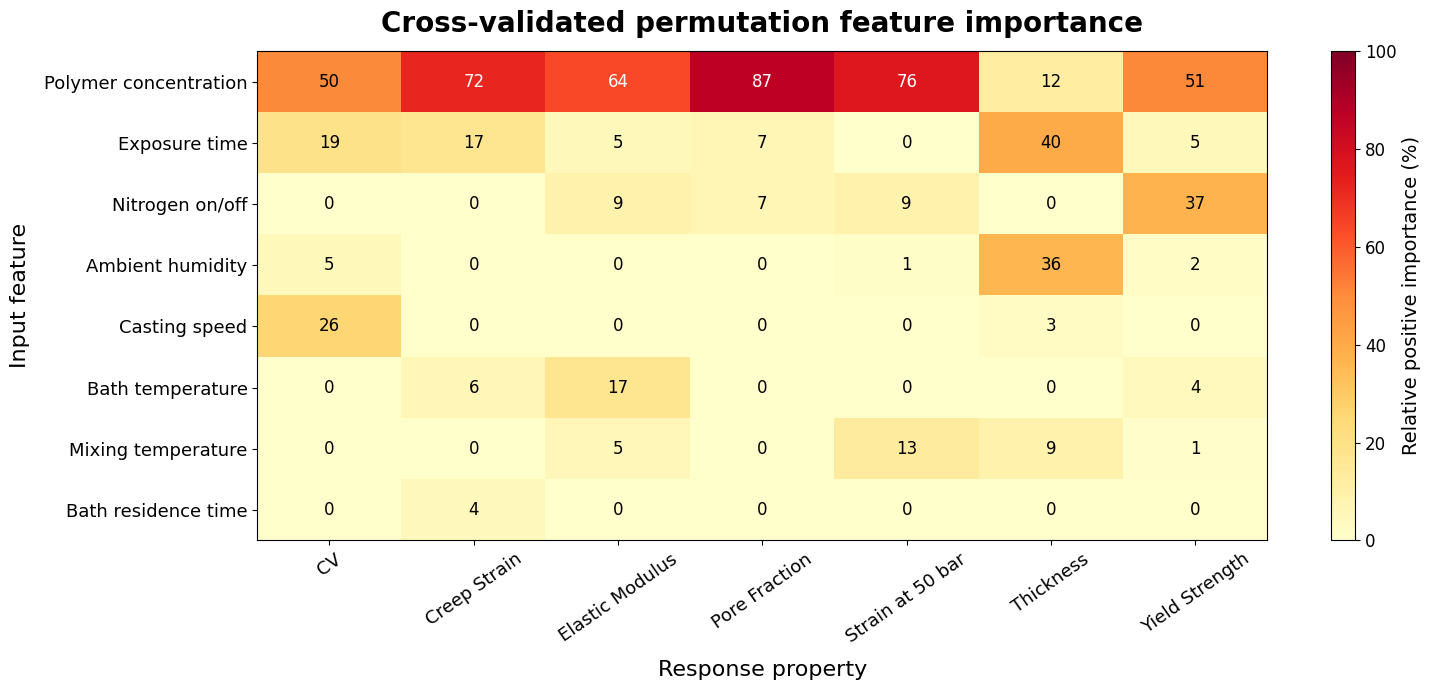

In [153]:
# Normalize positive importance within each property for a comparable 0–100% heatmap.
importance_for_plot = feature_importance.copy()
importance_for_plot['positive_importance'] = importance_for_plot['importance_mean'].clip(lower=0)
importance_for_plot['relative_importance'] = importance_for_plot.groupby('property')['positive_importance'].transform(
    lambda values: 100 * values / values.sum() if values.sum() > 0 else values
)
importance_matrix = importance_for_plot.pivot(index='feature', columns='property', values='relative_importance').fillna(0)
importance_matrix = importance_matrix.loc[importance_matrix.max(axis=1).sort_values(ascending=False).index]

figure_importance, importance_axis = plt.subplots(
    figsize=(max(12, 2.2 * len(importance_matrix.columns)), max(7, 0.8 * len(importance_matrix.index)))
)
heatmap = importance_axis.imshow(importance_matrix.to_numpy(), cmap='YlOrRd', vmin=0, vmax=100, aspect='auto')
importance_axis.set_xticks(range(len(importance_matrix.columns)))
importance_axis.set_xticklabels(importance_matrix.columns)
importance_axis.set_yticks(range(len(importance_matrix.index)))
importance_axis.set_yticklabels(importance_matrix.index)
for row_index in range(len(importance_matrix.index)):
    for column_index in range(len(importance_matrix.columns)):
        value = importance_matrix.iloc[row_index, column_index]
        importance_axis.text(column_index, row_index, f'{value:.0f}', ha='center', va='center',
                             fontsize=12, color='white' if value > 55 else 'black')
importance_colorbar = figure_importance.colorbar(heatmap, ax=importance_axis)
importance_colorbar.set_label('Relative positive importance (%)', fontsize=14)
importance_colorbar.ax.tick_params(labelsize=12)
importance_axis.set_title('Cross-validated permutation feature importance', fontsize=20, fontweight='semibold', pad=14)
importance_axis.set_xlabel('Response property', fontsize=16, labelpad=10)
importance_axis.set_ylabel('Input feature', fontsize=16, labelpad=10)
importance_axis.tick_params(axis='x', labelsize=13, rotation=35)
importance_axis.tick_params(axis='y', labelsize=13, rotation=0)
figure_importance.tight_layout()
plt.show()

## Linear SHAP analysis

For the standardized ridge model, the SHAP contribution under a mean-background/feature-independence assumption is `(standardized feature value) × (ridge coefficient)`. The contributions are additive: their sum plus the baseline prediction equals the model prediction. Positive values push a predicted property upward; negative values push it downward.

The first figure summarizes global mean absolute SHAP magnitude. It is followed by a signed per-iteration contribution plot for every modeled response; point color indicates the original feature value. These are model explanations, not causal effects. Correlated campaign settings can redistribute attribution among features.

In [154]:
def calculate_linear_shap(data, properties, features=FEATURES):
    shap_records = []
    prediction_records = []
    for property_name in properties:
        target_column = f'{property_name} Mean'
        usable = data.dropna(subset=[target_column]).copy()
        if len(usable) < MIN_TARGET_SAMPLES:
            continue
        X = usable[list(features)].copy()
        X['nitrogen'] = X['nitrogen'].map(nitrogen_to_binary)
        X = X.apply(pd.to_numeric, errors='coerce')
        variable_columns = [column for column in X if X[column].nunique(dropna=True) > 1]
        X = X[variable_columns]
        medians = X.median()
        X_numeric = X.fillna(medians).to_numpy(dtype=float)
        center, scale = X_numeric.mean(axis=0), X_numeric.std(axis=0)
        scale[scale == 0] = 1
        X_standardized = (X_numeric - center) / scale
        y = pd.to_numeric(usable[target_column], errors='coerce').to_numpy(dtype=float)
        baseline = y.mean()
        coefficients = np.linalg.solve(
            X_standardized.T @ X_standardized + RIDGE_ALPHA * np.eye(X_standardized.shape[1]),
            X_standardized.T @ (y - baseline),
        )
        shap_values = X_standardized * coefficients
        predictions = baseline + shap_values.sum(axis=1)
        for row_position, (_, sample) in enumerate(usable.iterrows()):
            prediction_records.append({
                'property': property_name, 'iteration': sample['iteration'],
                'observed': y[row_position], 'prediction': predictions[row_position],
                'baseline': baseline,
            })
            for feature_position, feature in enumerate(variable_columns):
                shap_records.append({
                    'property': property_name, 'iteration': sample['iteration'],
                    'feature': features[feature], 'feature_column': feature,
                    'feature_value': X_numeric[row_position, feature_position],
                    'shap_value': shap_values[row_position, feature_position],
                })
    return pd.DataFrame(shap_records), pd.DataFrame(prediction_records)

shap_values, shap_predictions = calculate_linear_shap(
    campaign_detailed, FEATURE_IMPORTANCE_PROPERTIES
)
# Numerical check of the additive SHAP identity.
assert np.allclose(
    shap_predictions['prediction'],
    shap_predictions['baseline'] + shap_values.groupby(['property', 'iteration'])['shap_value'].sum().reindex(
        pd.MultiIndex.from_frame(shap_predictions[['property', 'iteration']])
    ).to_numpy(),
)
shap_values.head()

,property,iteration,feature,feature_column,feature_value,shap_value
0,Thickness,1,Polymer concentration,polymer_wt,17.0,1.816356
1,Thickness,1,Mixing temperature,mixing_temp,25.0,-1.845772
2,Thickness,1,Bath temperature,bath_temp,5.0,0.835981
3,Thickness,1,Casting speed,pullcast_speed,10.0,-0.339784
4,Thickness,1,Nitrogen on/off,nitrogen,1.0,0.527527


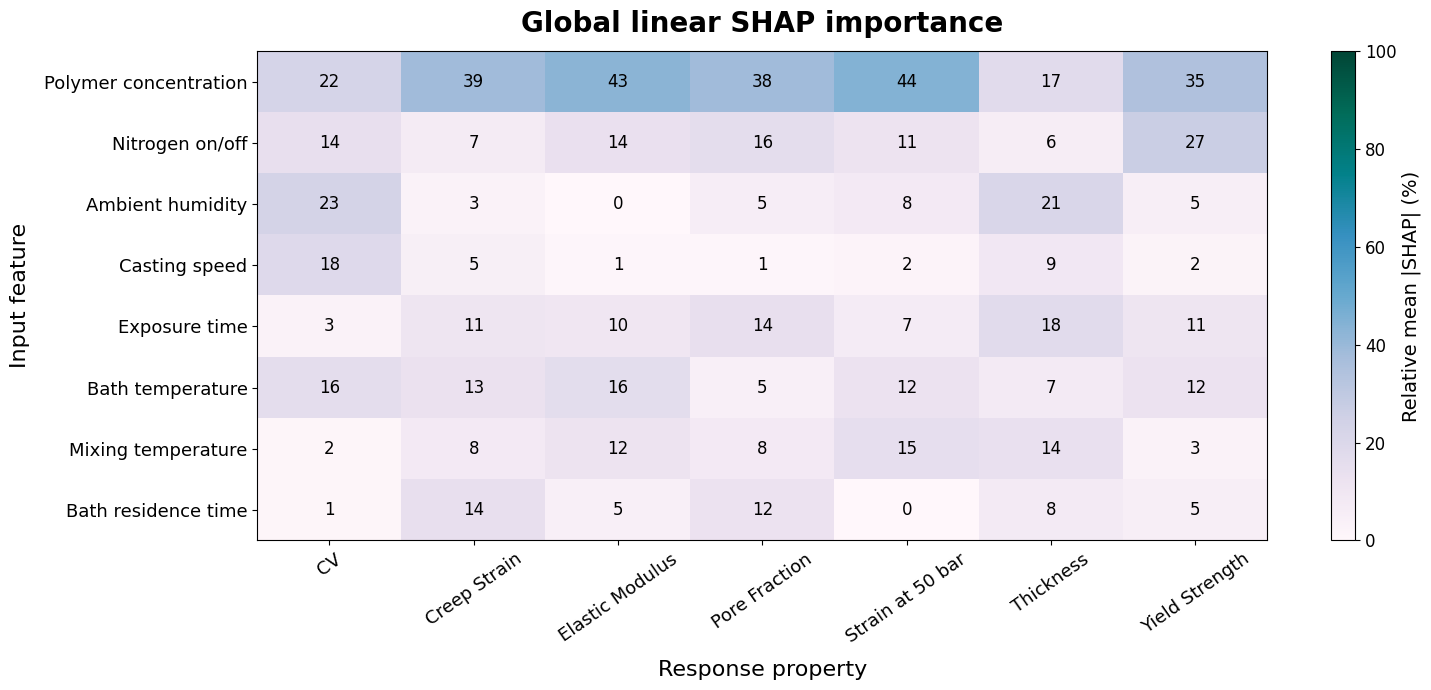

In [155]:
global_shap = (shap_values.assign(abs_shap=lambda frame: frame['shap_value'].abs())
               .groupby(['feature', 'property'], as_index=False)['abs_shap'].mean())
global_shap['relative_mean_abs_shap'] = global_shap.groupby('property')['abs_shap'].transform(
    lambda values: 100 * values / values.sum() if values.sum() > 0 else values
)
shap_matrix = global_shap.pivot(index='feature', columns='property', values='relative_mean_abs_shap').fillna(0)
shap_matrix = shap_matrix.loc[shap_matrix.max(axis=1).sort_values(ascending=False).index]

figure_shap_global, shap_global_axis = plt.subplots(
    figsize=(max(12, 2.2 * len(shap_matrix.columns)), max(7, 0.8 * len(shap_matrix.index)))
)
shap_image = shap_global_axis.imshow(shap_matrix.to_numpy(), cmap='PuBuGn', vmin=0, vmax=100, aspect='auto')
shap_global_axis.set_xticks(range(len(shap_matrix.columns)))
shap_global_axis.set_xticklabels(shap_matrix.columns)
shap_global_axis.set_yticks(range(len(shap_matrix.index)))
shap_global_axis.set_yticklabels(shap_matrix.index)
for row_index in range(len(shap_matrix.index)):
    for column_index in range(len(shap_matrix.columns)):
        value = shap_matrix.iloc[row_index, column_index]
        shap_global_axis.text(column_index, row_index, f'{value:.0f}', ha='center', va='center',
                              fontsize=12, color='white' if value > 55 else 'black')
shap_global_colorbar = figure_shap_global.colorbar(shap_image, ax=shap_global_axis)
shap_global_colorbar.set_label('Relative mean |SHAP| (%)', fontsize=14)
shap_global_colorbar.ax.tick_params(labelsize=12)
shap_global_axis.set_title('Global linear SHAP importance', fontsize=20, fontweight='semibold', pad=14)
shap_global_axis.set_xlabel('Response property', fontsize=16, labelpad=10)
shap_global_axis.set_ylabel('Input feature', fontsize=16, labelpad=10)
shap_global_axis.tick_params(axis='x', labelsize=13, rotation=35)
shap_global_axis.tick_params(axis='y', labelsize=13)
figure_shap_global.tight_layout()
plt.show()

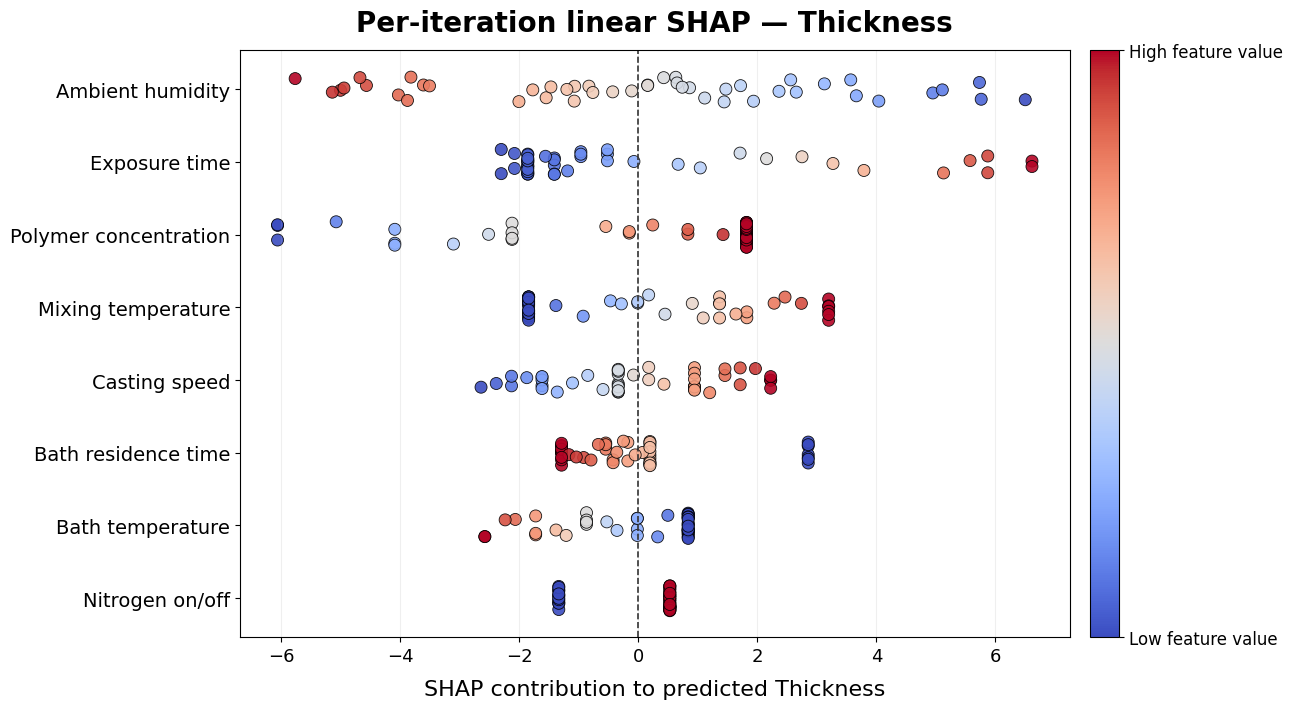

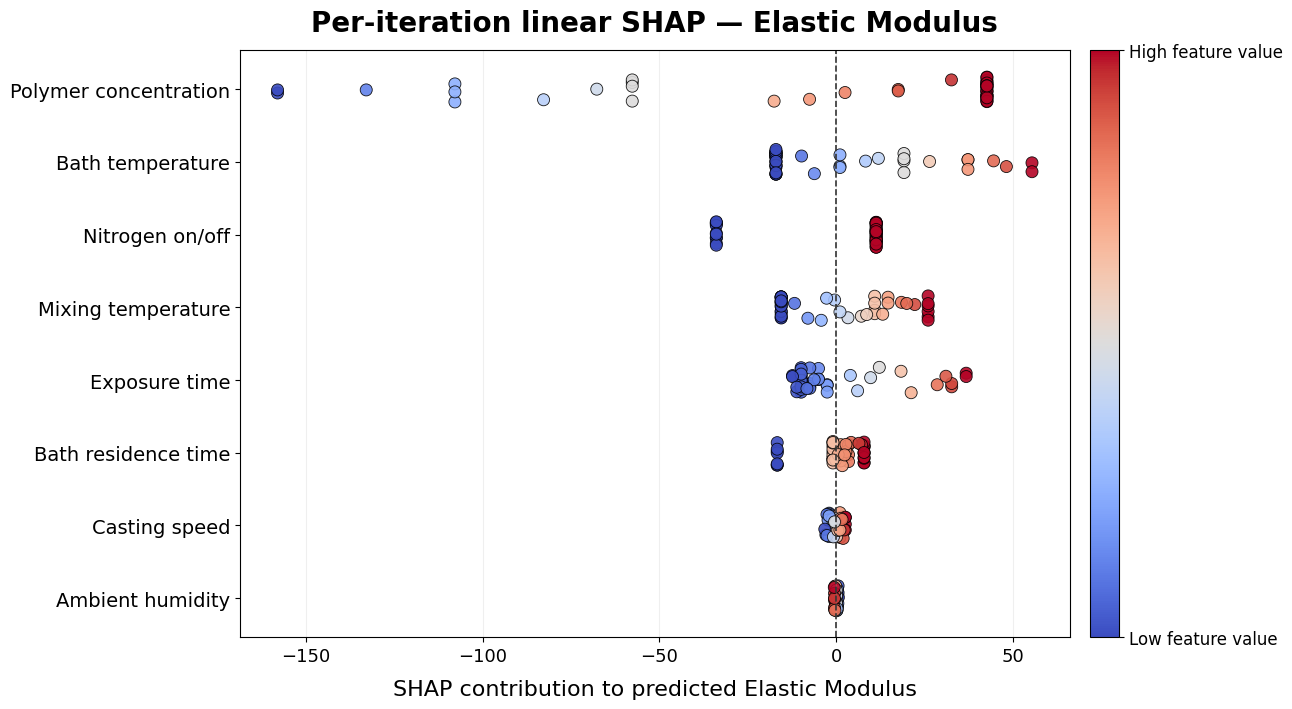

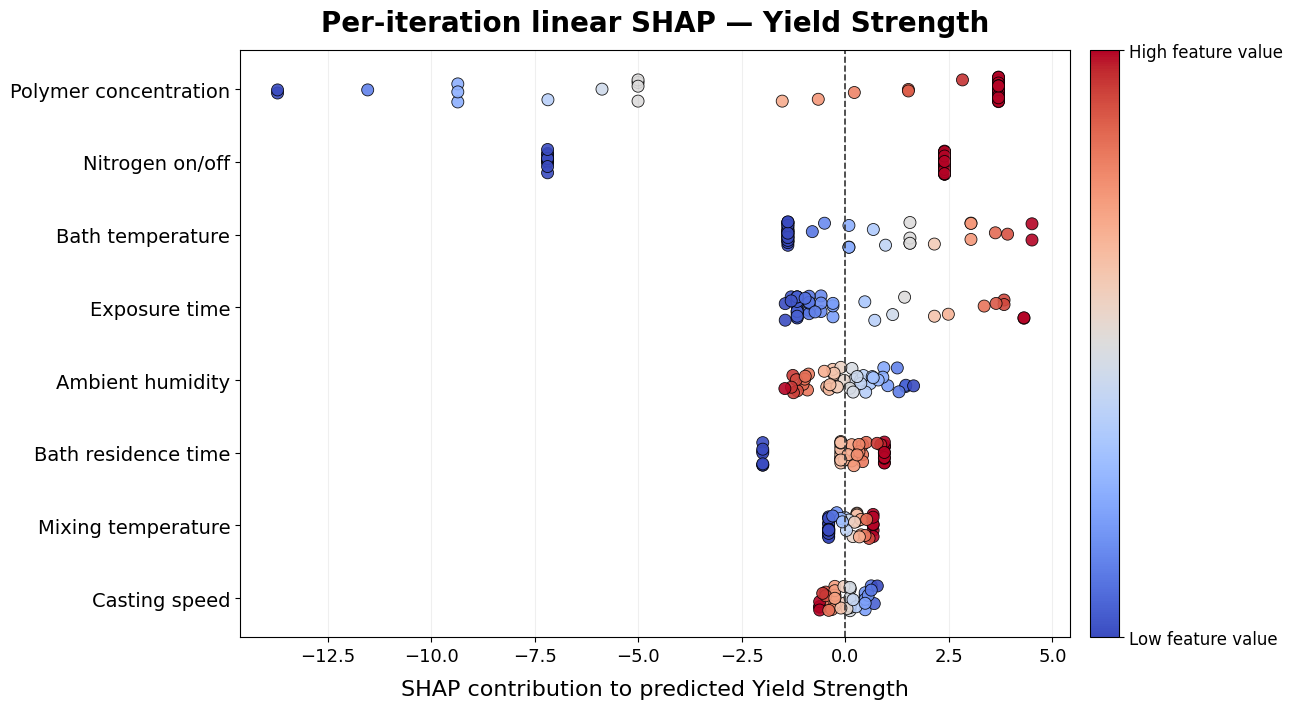

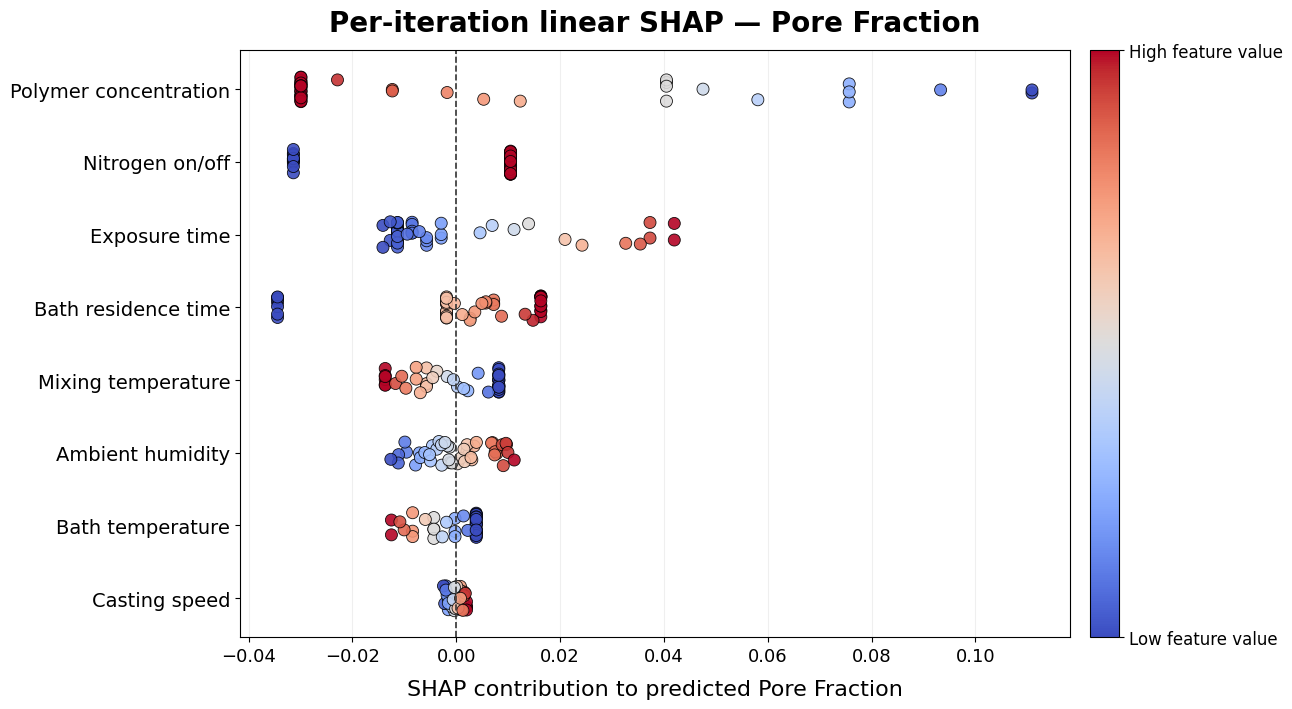

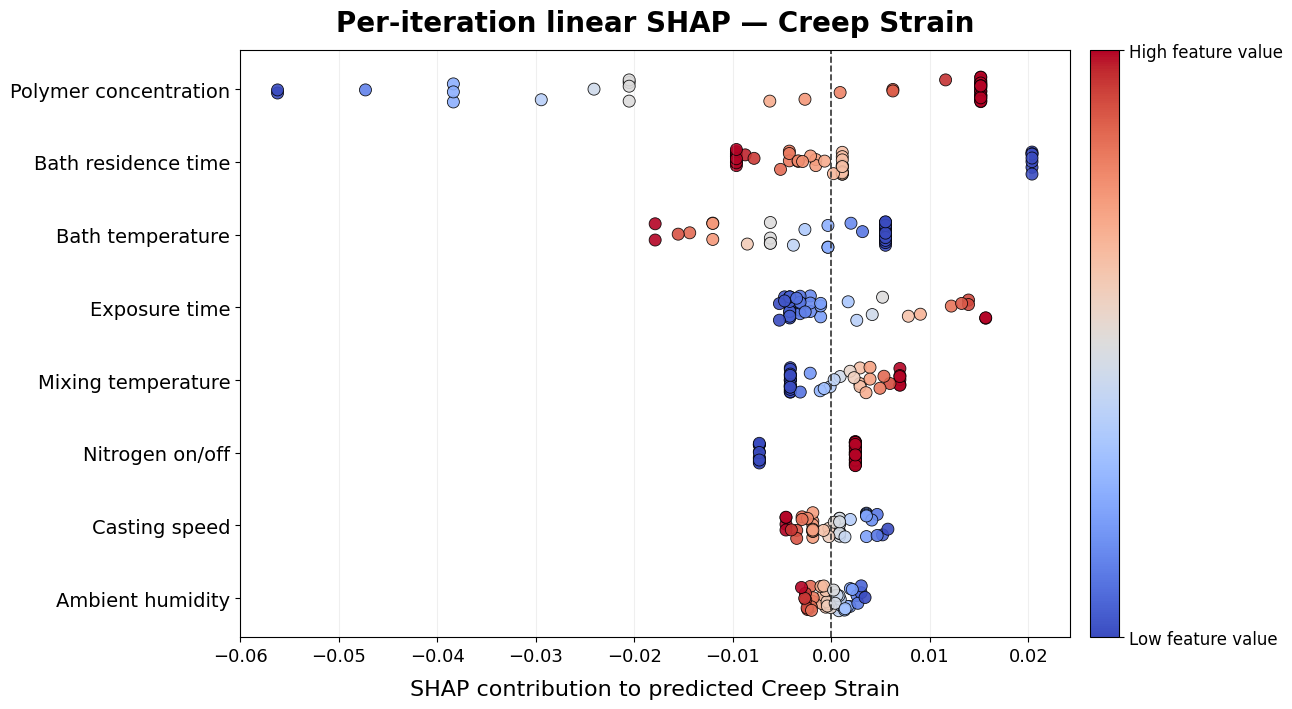

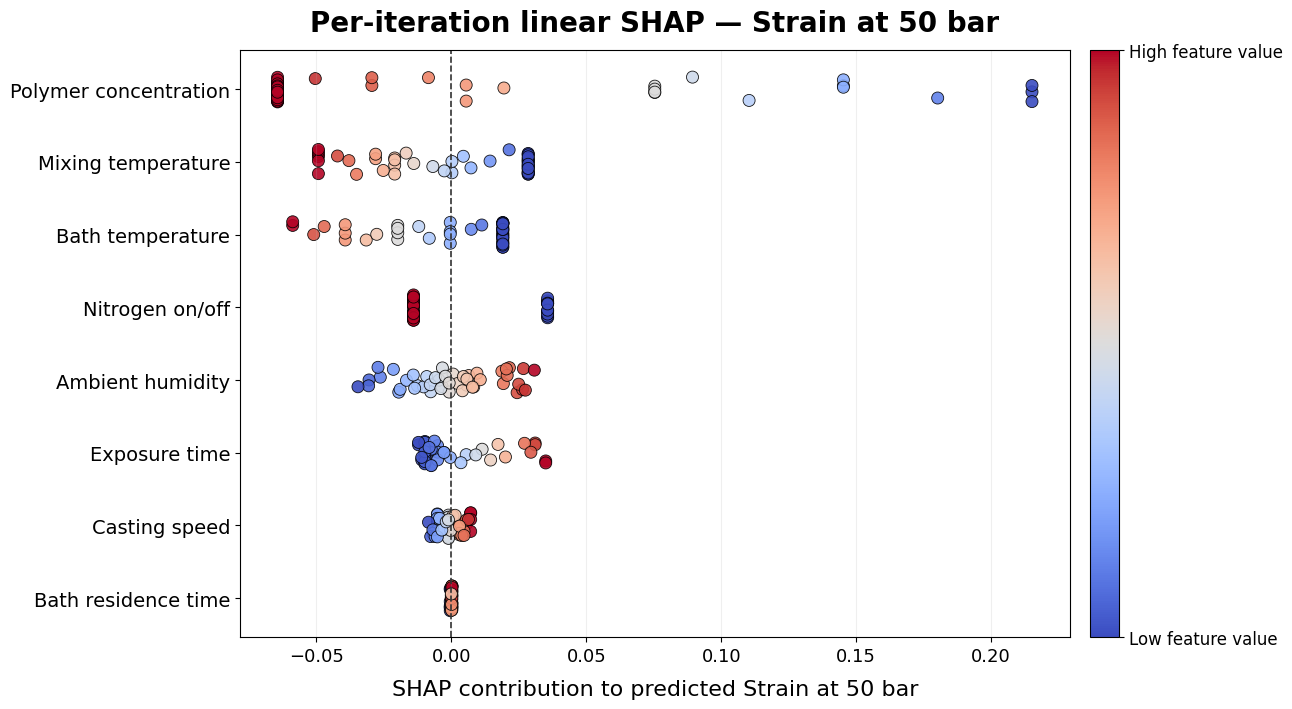

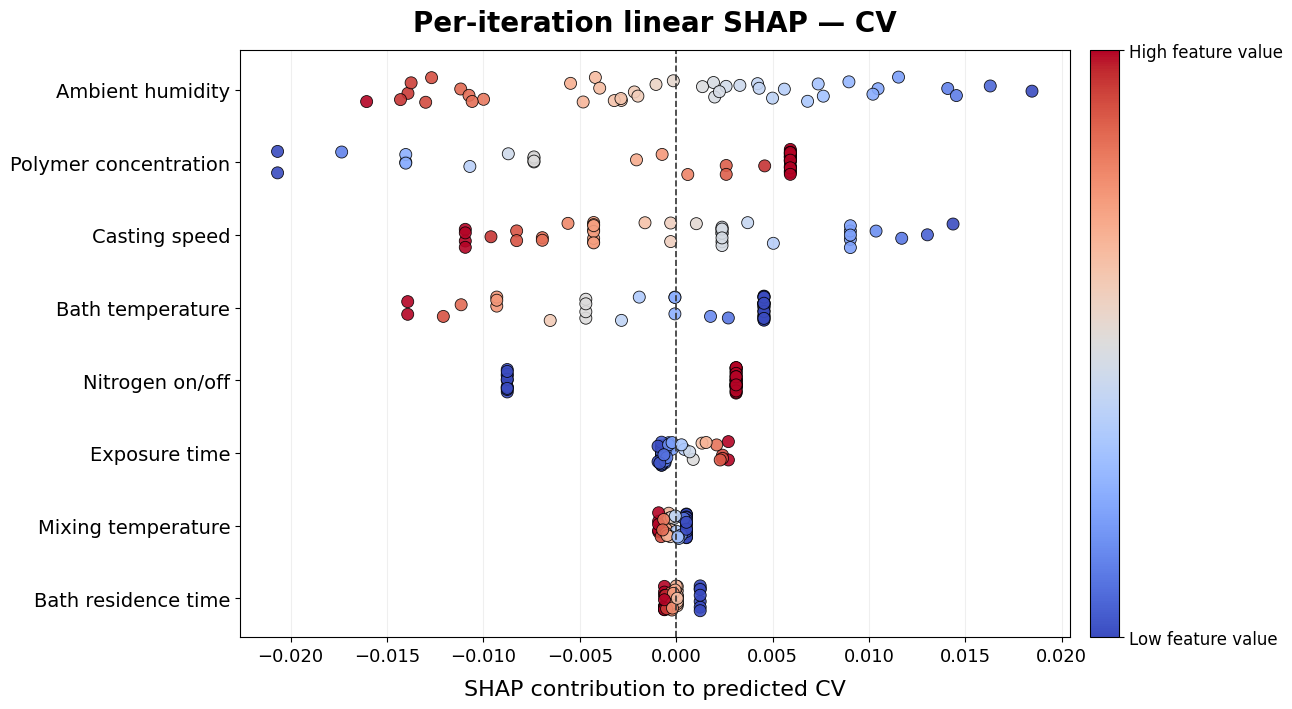

In [156]:
def plot_shap_detail(detail, property_name):
    feature_order = (detail.assign(abs_shap=detail['shap_value'].abs())
                     .groupby('feature')['abs_shap'].mean().sort_values(ascending=True).index.tolist())
    figure, axis = plt.subplots(figsize=(13, max(7, 0.9 * len(feature_order))))
    jitter_generator = np.random.RandomState(RANDOM_STATE)
    for feature_position, feature in enumerate(feature_order):
        feature_points = detail[detail['feature'] == feature].copy()
        values = feature_points['feature_value'].to_numpy(dtype=float)
        value_min, value_max = np.nanmin(values), np.nanmax(values)
        normalized_values = np.full(len(values), 0.5) if value_min == value_max else (values - value_min) / (value_max - value_min)
        vertical_positions = feature_position + jitter_generator.uniform(-0.18, 0.18, len(feature_points))
        axis.scatter(feature_points['shap_value'], vertical_positions, c=normalized_values,
                     cmap='coolwarm', vmin=0, vmax=1, s=75, edgecolor='black', linewidth=0.6, alpha=0.9)
    axis.axvline(0, color='#333333', linestyle='--', linewidth=1.2)
    axis.set_yticks(range(len(feature_order)))
    axis.set_yticklabels(feature_order, fontsize=14)
    axis.set_xlabel(f'SHAP contribution to predicted {property_name}', fontsize=16, labelpad=10)
    axis.set_title(f'Per-iteration linear SHAP — {property_name}', fontsize=20, fontweight='semibold', pad=14)
    axis.tick_params(axis='x', labelsize=13)
    axis.grid(axis='x', alpha=0.2)
    color_scale = plt.cm.ScalarMappable(norm=plt.Normalize(0, 1), cmap='coolwarm')
    color_scale.set_array([])
    colorbar = figure.colorbar(color_scale, ax=axis, pad=0.02)
    colorbar.set_ticks([0, 1])
    colorbar.set_ticklabels(['Low feature value', 'High feature value'])
    colorbar.ax.tick_params(labelsize=12)
    figure.tight_layout()
    return figure, axis

figure_shap_details = {}
axes_shap_details = {}
for property_name in FEATURE_IMPORTANCE_PROPERTIES:
    detail = shap_values[shap_values['property'] == property_name].copy()
    if detail.empty:
        continue
    figure_shap_details[property_name], axes_shap_details[property_name] = plot_shap_detail(
        detail, property_name
    )
    plt.show()

In [157]:
# Optional explicit export of the enhanced figure/data; nothing is written otherwise.
if SAVE_OUTPUTS:
    output_dir = repo_root / 'EVALUATE' / 'campaign_trends_output'
    output_dir.mkdir(parents=True, exist_ok=True)
    csv_path = output_dir / 'campaign_data_detailed.csv'
    polymer_png = output_dir / 'campaign_properties_by_polymer.png'
    humidity_png = output_dir / 'campaign_properties_by_humidity_nitrogen.png'
    exposure_png = output_dir / 'campaign_properties_by_exposure_time.png'
    bath_png = output_dir / 'campaign_properties_by_bath_temperature.png'
    casting_png = output_dir / 'campaign_properties_by_casting_speed.png'
    importance_csv = output_dir / 'campaign_feature_importance.csv'
    importance_png = output_dir / 'campaign_feature_importance.png'
    shap_values_csv = output_dir / 'campaign_linear_shap_values.csv'
    shap_predictions_csv = output_dir / 'campaign_linear_shap_predictions.csv'
    shap_global_png = output_dir / 'campaign_linear_shap_global.png'
    campaign_detailed.to_csv(csv_path, index=False)
    figure_polymer.savefig(polymer_png, dpi=180, bbox_inches='tight')
    figure_humidity.savefig(humidity_png, dpi=180, bbox_inches='tight')
    figure_exposure.savefig(exposure_png, dpi=180, bbox_inches='tight')
    figure_bath.savefig(bath_png, dpi=180, bbox_inches='tight')
    figure_casting.savefig(casting_png, dpi=180, bbox_inches='tight')
    feature_importance.to_csv(importance_csv, index=False)
    figure_importance.savefig(importance_png, dpi=180, bbox_inches='tight')
    shap_values.to_csv(shap_values_csv, index=False)
    shap_predictions.to_csv(shap_predictions_csv, index=False)
    figure_shap_global.savefig(shap_global_png, dpi=180, bbox_inches='tight')
    shap_detail_paths = []
    for property_name, detail_figure in figure_shap_details.items():
        safe_property = property_name.lower().replace(' ', '_')
        detail_path = output_dir / f'campaign_linear_shap_{safe_property}.png'
        detail_figure.savefig(detail_path, dpi=180, bbox_inches='tight')
        shap_detail_paths.append(detail_path)
    all_saved_paths = [csv_path, polymer_png, humidity_png, exposure_png, bath_png, casting_png,
                       importance_csv, importance_png, shap_values_csv, shap_predictions_csv,
                       shap_global_png] + shap_detail_paths
    print('Saved ' + '\nSaved '.join(str(path) for path in all_saved_paths))